Read in python modules 

In [71]:
import altair as alt 
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(font_scale=1.0, style='ticks', palette='colorblind')

Read in fitness effects

In [2]:
f='../results/fitness.csv'
fitness_df = pd.read_csv(f, keep_default_na=False)
fitness_df.head()

,subtype,segment,gene,codon_site,wt_aa,mut_aa,mut_class,actual_count,rate,mean_syn_rate,evo_opp,delta_fitness,expected_count,expected_count_lower_bound
0,H1N1,HA,HA,507,S,L,nonsynonymous,19,0.301239,1.786959,63.072941,-1.780368,112.708778,6.307294
1,H1N1,HA,HA,507,S,P,nonsynonymous,0,0.100000,1.441764,62.737059,-2.668452,90.452011,6.273706
2,H1N1,HA,HA,507,S,S,synonymous,67,1.063194,1.860076,189.052941,-0.559339,351.652781,18.905294
3,H1N1,HA,HA,508,E,E,synonymous,139,2.233818,2.956514,62.225294,-0.280299,183.969978,6.222529
4,H1N1,HA,HA,508,E,G,nonsynonymous,24,0.385695,1.446053,62.225294,-1.321545,89.981043,6.222529


Read in DMS data

In [3]:
f = '../data/dms_data/Yu_HA/Phenotypes.csv'
dms_df = pd.read_csv(f)
dms_df.rename(
    columns={
        'site' : 'codon_site',
        'MDCKSIAT1 cell entry' : 'dms_effect',
        'sera escape' : 'sera_escape',
        'pH stability' : 'pH_stability',
        'wildtype' : 'wt_aa',
        'mutant' : 'mut_aa',
        'nt changes to codon' : 'n_nt_changes'
    },
    inplace=True
)
dms_df.head()

,codon_site,wt_aa,mut_aa,sera_escape,dms_effect,pH_stability,sequential_site,region,n_nt_changes
0,1,Q,A,0.08825,-0.1226,0.004237,1,HA1,2
1,1,Q,C,0.01779,-0.5732,-0.014300,1,HA1,3
2,1,Q,D,-0.05395,0.2550,-0.021900,1,HA1,2
3,1,Q,E,-0.01963,0.2941,0.006890,1,HA1,1
4,1,Q,F,-0.16350,-0.7141,-0.001402,1,HA1,3


Merge fitness data with DMS data

In [19]:
data =  fitness_df[
        (fitness_df['gene'] == 'HA') &
        (fitness_df['subtype'] == 'H3N2')
]
data['codon_site'] = data['codon_site'].astype(int)

ha_mut_effects = (
    data
    .assign(codon_site = lambda x: x['codon_site'] - 16)
    .merge(dms_df, on=['codon_site', 'wt_aa', 'mut_aa'], how='inner')
)
ha_mut_effects['dms_effect'] = ha_mut_effects['dms_effect'].clip(lower=-3)
ha_mut_effects['delta_fitness'] = ha_mut_effects['delta_fitness'].clip(lower=-3)
ha_mut_effects['difference_n_l'] = ha_mut_effects['delta_fitness'] - ha_mut_effects['dms_effect']
print(len(data))
data.head()

1873


/var/folders/fv/32sft10n6m5bgntl6_6k7d0r0000gq/T/ipykernel_38784/218581716.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['codon_site'] = data['codon_site'].astype(int)


,subtype,segment,gene,codon_site,wt_aa,mut_aa,mut_class,actual_count,rate,mean_syn_rate,evo_opp,delta_fitness,expected_count,expected_count_lower_bound
13310,H3N2,HA,HA,1,M,I,nonsynonymous,22,0.369028,3.624405,234.176471,-2.284573,848.750341,23.417647
13311,H3N2,HA,HA,1,M,T,nonsynonymous,0,0.100000,1.441764,78.063529,-2.668452,112.549159,7.806353
13312,H3N2,HA,HA,1,M,V,nonsynonymous,0,0.100000,1.446053,78.063529,-2.671423,112.883963,7.806353
13313,H3N2,HA,HA,2,K,E,nonsynonymous,25,0.324375,1.446053,77.071176,-1.494691,111.448969,7.707118
13314,H3N2,HA,HA,2,K,K,synonymous,134,4.003485,5.913029,77.076471,-0.389993,455.755391,7.707647


Compare fitness effects between nature and the DMS experiment

<Axes: xlabel='dms_effect', ylabel='delta_fitness'>

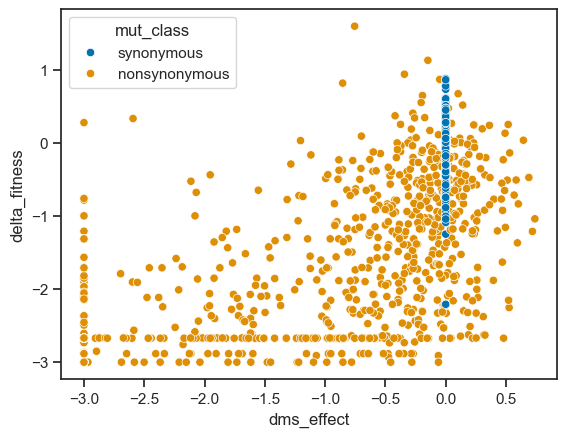

In [12]:
sns.scatterplot(x='dms_effect',y='delta_fitness',data=ha_mut_effects, hue='mut_class')


**Observations**:First Plot of data 
* there is a trsyn mutations have a cell entry (0) = neutral 
* non syn mutations have a negative delta fitness and negatvie cell entry= Deleterious effect in Nature and Experimental 
* Most of the mutation points are non syn
* Cell entry(experimental delta fitness): 0 neutral (-): deleterious effect (+)- beneficial effect 
*Middle right: fitness effect in lab neutral but fitness effect in nature is deleterious 
*Top right: Neutral in both 
*Bottom left: Bad in both (-)
* Most points are below the trend line/ COVID they are above the trend line 
There are limitations because the lab cannot completely replicate nature but we do except some similarities. 
Hemagluttin protein 


In [22]:
    
heatmap = alt.Chart(ha_mut_effects).mark_rect().encode(
    x=alt.X('codon_site:O', title='site'),
    y=alt.Y('mut_aa:O', title='Amino Acid'),
    color=alt.Color('difference_n_l:Q', title='Fitness', scale=alt.Scale(range=['red', 'white', 'black'], # Custom blue-grey-red range
                                    domainMid=0))
).properties(
    title='My Altair Heatmap'
)
heatmap.display()

alt.Chart(...)

**Observations** 
Difference = fitness in nature - fitness in lab 
**if (-) fitness in nature is less than fitness in lab (more fit in lab/ bottom right corner if scatter plot)**
* Heat map looks over fitness of nature and lab 
* At site 416-448 there are a large amount of muations sites that have both effects from ranging amino acids 
* Few that are completely deletrious in both nature and lab 
* Amino Acid G has great variation accross the sites
**Red -2 (Deletrious effects)**
**Black 2 (good effects)**
**Light grey -> White (neutral)**
Mutations do not show a show a distinctive difference between nature and lab. The data varies across the sites and amino aicds. 
Final
Residues 100-120 most differences are there but there were no hot spots 
**Confident that there are difference but they didnt form patterns that we expcetec within the protein**



# muts 1039
Pearson R 0.6295867522058594


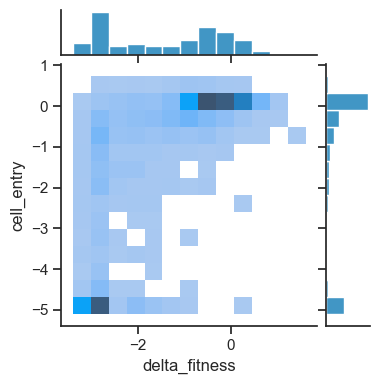

In [10]:
data_to_plot = data[data['mut_class'] == 'nonsynonymous']
print('# muts', len(data_to_plot))
print('Pearson R', data_to_plot['cell_entry'].corr(data_to_plot['delta_fitness']))
sns.jointplot(x='delta_fitness', y='cell_entry', data=data, kind='hist', height=4)
sns.despine()
plt.show()

## Compare fitness in the Lab for nature for nucleoprotein

In [42]:
pi_dict = {}
for col in np_dms_data.columns:
    if 'PI'in col: 
        pi_dict[col] = col[-1]
pi_dict
   

{'PI_A': 'A',
 'PI_C': 'C',
 'PI_D': 'D',
 'PI_E': 'E',
 'PI_F': 'F',
 'PI_G': 'G',
 'PI_H': 'H',
 'PI_I': 'I',
 'PI_K': 'K',
 'PI_L': 'L',
 'PI_M': 'M',
 'PI_N': 'N',
 'PI_P': 'P',
 'PI_Q': 'Q',
 'PI_R': 'R',
 'PI_S': 'S',
 'PI_T': 'T',
 'PI_V': 'V',
 'PI_W': 'W',
 'PI_Y': 'Y'}

In [73]:
# read in file 
np_dms= '../data/dms_data/Bloom_NP/Supplementary_file_1.xls' 
np_dms_data = pd.read_excel(np_dms) 

#create a dict to rename the coluns 
col_dict= {
    '#SITE' : 'site',
    'WT_AA':'wt_aa',
    }
aa_cols = []
for col in np_dms_data.columns:
    if 'PI'in col: 
        aa = col[-1]
        col_dict[col] = aa
        aa_cols.append(aa)
np_dms_data.rename(columns= col_dict, inplace=True)

#Melt dataframe 
np_dms_data = pd.melt(
    np_dms_data, id_vars=['site', 'wt_aa'],  value_vars=aa_cols,
    var_name='mut_aa', value_name='preferences'
)

#Make a smaller dataframe with only row wt_aa = mut_aa 
wt_data = np_dms_data[np_dms_data['wt_aa'] == np_dms_data['mut_aa']].copy()
wt_data.rename(columns={'preferences': 'wt_preferences'}, inplace=True)

#Merge the smaller dataframe with the original dataframe, (not merging on wt_aa and mut_aa columns from smaller dataframe)
np_dms_data = np_dms_data.merge( wt_data[['site', 'wt_preferences']], on='site')

#Add a column that quantivies the mutation effect (prefernces/wt_prefernce)
np_dms_data['dms_effect'] = np.log(np_dms_data['preferences'] / np_dms_data['wt_preferences'])

#Merge nature and dms data 
nature_df= fitness_df[
        (fitness_df['gene'] == 'NP') &
        (fitness_df['subtype'] == 'H3N2')
]
np_dms_data = np_dms_data.merge(nature_df) 
np_dms_data.head()

,site,wt_aa,mut_aa,preferences,wt_preferences,dms_effect,subtype,segment,gene,codon_site,mut_class,actual_count,rate,mean_syn_rate,evo_opp,delta_fitness,expected_count,expected_count_lower_bound
0,2,A,A,0.753436,0.753436,0.0,H3N2,NP,NP,2,synonymous,42,1.199034,3.624405,111.916444,-1.106174,405.630505,11.191644
1,2,A,A,0.753436,0.753436,0.0,H3N2,NP,NP,22,synonymous,36,1.027168,1.860076,106.776738,-0.593811,198.612815,10.677674
2,2,A,A,0.753436,0.753436,0.0,H3N2,NP,NP,27,synonymous,70,1.888719,1.860076,111.186497,0.015281,206.815301,11.118650
3,2,A,A,0.753436,0.753436,0.0,H3N2,NP,NP,70,synonymous,63,1.749935,1.906278,108.004011,-0.085574,205.885621,10.800401
4,2,A,A,0.753436,0.753436,0.0,H3N2,NP,NP,85,synonymous,218,6.229765,3.624405,106.692513,0.541648,386.696865,10.669251


In [61]:
np_dms_data.head()

,site,wt_aa,mut_aa,preferences
0,1,M,A,0.026720
1,2,A,A,0.753436
2,3,S,A,0.059008
3,4,Q,A,0.020215
4,5,G,A,0.114320


Read in data from the file 

Analyze the distribution of fitness effect for H3N2 for syn, non syn, and nonsense 

In [ ]:
fitness_df.head()

,subtype,segment,gene,codon_site,wt_aa,mut_aa,mut_class,actual_count,rate,mean_syn_rate,evo_opp,delta_fitness,expected_count,expected_count_lower_bound
0,H1N1,HA,HA,507,S,L,nonsynonymous,19,0.301239,1.786959,63.072941,-1.780368,112.708778,6.307294
1,H1N1,HA,HA,507,S,P,nonsynonymous,0,0.100000,1.441764,62.737059,-2.668452,90.452011,6.273706
2,H1N1,HA,HA,507,S,S,synonymous,67,1.063194,1.860076,189.052941,-0.559339,351.652781,18.905294
3,H1N1,HA,HA,508,E,E,synonymous,139,2.233818,2.956514,62.225294,-0.280299,183.969978,6.222529
4,H1N1,HA,HA,508,E,G,nonsynonymous,24,0.385695,1.446053,62.225294,-1.321545,89.981043,6.222529


In [19]:
data = fitness_df[fitness_df['subtype'] == 'H3N2'] 


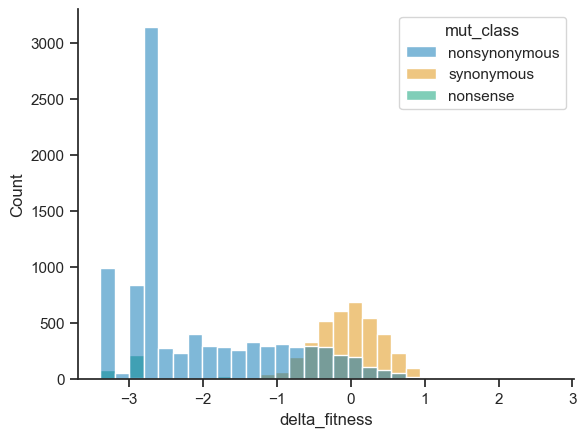

In [20]:
sns.histplot(x='delta_fitness', data=data, hue='mut_class')
sns.despine()
plt.show()

B) Analyze the distribution of fitness effect for H3N2 for syn, non syn, and nonsense

<Axes: xlabel='segment', ylabel='delta_fitness'>

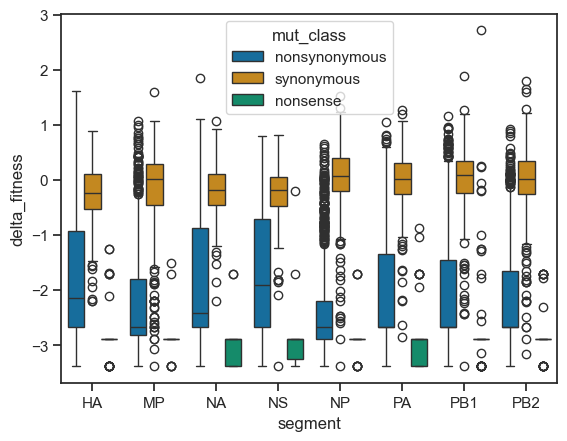

In [21]:
sns.boxplot(x='segment', y='delta_fitness', data=data, hue='mut_class')

**Observations**
* All of the segments/chromosomes of the human genomes (encode a single gene), follow a trend of 
    * Syn- being neutral(at 0) or benefical because of the positive number 
    * non - syn or deleterious/ bad (-1 and below)
    * all have nonsense, but NS and PA are the 2 most prominent genes with significant nonsense mutations 
* All genes are under a large amount constraint 
    *Specfifc to evolution - they are importnant for fitness, when a mutation happens it becomes bad 
    * When a does genes does not have constraint - mutation do not normally change the fitness of the gene in the hamn genome 

In [18]:
ha_mut_effects

,subtype,segment,gene,codon_site,wt_aa,mut_aa,mut_class,actual_count,rate,mean_syn_rate,...,delta_fitness,expected_count,expected_count_lower_bound,sera_escape,dms_effect,pH_stability,sequential_site,region,n_nt_changes,difference_n_l]
0,H3N2,HA,HA,1,Q,Q,synonymous,75,0.985225,1.446053,...,-0.383722,110.080323,7.612471,0.000000,0.00000,0.000000,1,HA1,0,-0.383722
1,H3N2,HA,HA,1,Q,R,nonsynonymous,17,0.219986,1.446053,...,-1.883029,111.747536,7.727765,-0.192300,-0.88610,0.012610,1,HA1,1,-0.996929
2,H3N2,HA,HA,2,K,E,nonsynonymous,74,0.983250,1.446053,...,-0.385729,108.830763,7.526059,-0.068890,-0.31980,0.050210,2,HA1,1,-0.065929
3,H3N2,HA,HA,2,K,K,synonymous,92,2.900340,2.892105,...,0.002843,217.295760,7.513412,0.000000,0.00000,0.000000,2,HA1,0,0.002843
4,H3N2,HA,HA,2,K,R,nonsynonymous,59,0.782499,1.446053,...,-0.614099,109.031509,7.539941,-0.102400,-0.61280,0.060580,2,HA1,1,-0.001299
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1507,H3N2,HA,HA,503,K,K,synonymous,505,7.047861,2.956514,...,0.868713,211.842953,7.165294,0.000000,0.00000,0.000000,503,HA2,0,0.868713
1508,H3N2,HA,HA,503,K,R,nonsynonymous,78,1.088295,1.446053,...,-0.284225,103.641136,7.167176,-0.041060,0.17440,0.005226,503,HA2,1,-0.458625
1509,H3N2,HA,HA,504,G,D,nonsynonymous,71,0.957587,2.956514,...,-1.127350,219.209891,7.414471,-0.003735,-0.91920,-0.064430,504,HA2,2,-0.208150
1510,H3N2,HA,HA,504,G,G,synonymous,6,0.300000,2.726776,...,-2.207093,601.273305,22.050706,0.000000,0.00000,0.000000,504,HA2,0,-2.207093


In [ ]:
f='../results/fitness.csv'
df = pd.read_csv(f)

In [3]:
df

,subtype,segment,gene,codon_site,wt_aa,mut_aa,mut_class,actual_count,rate,mean_syn_rate,evo_opp,delta_fitness,expected_count,expected_count_lower_bound
0,H1N1,HA,HA,507,S,L,nonsynonymous,19,0.301239,1.786959,63.072941,-1.780368,112.708778,6.307294
1,H1N1,HA,HA,507,S,P,nonsynonymous,0,0.100000,1.441764,62.737059,-2.668452,90.452011,6.273706
2,H1N1,HA,HA,507,S,S,synonymous,67,1.063194,1.860076,189.052941,-0.559339,351.652781,18.905294
3,H1N1,HA,HA,508,E,E,synonymous,139,2.233818,2.956514,62.225294,-0.280299,183.969978,6.222529
4,H1N1,HA,HA,508,E,G,nonsynonymous,24,0.385695,1.446053,62.225294,-1.321545,89.981043,6.222529
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36674,H9N2,HA,ha,560,I,M,nonsynonymous,1,0.100000,1.446053,11.802616,-2.671423,17.067203,1.180262
36675,H9N2,HA,ha,560,I,T,nonsynonymous,2,0.169454,1.441764,11.802616,-2.141041,17.016583,1.180262
36676,H9N2,HA,ha,560,I,V,nonsynonymous,12,1.017031,1.446053,11.799049,-0.351950,17.062044,1.179905
36677,H9N2,HA,ha,561,*,*,synonymous,28,2.467697,2.892105,22.693222,-0.158699,65.631183,2.269322


Get data for the HA gene from the H3N2 subtype 

In [53]:
df['subtype'] #to look at a specific column in the dataframe 

0        H1N1
1        H1N1
2        H1N1
3        H1N1
4        H1N1
         ... 
36674    H9N2
36675    H9N2
36676    H9N2
36677    H9N2
36678    H9N2
Name: subtype, Length: 36679, dtype: object

In [ ]:
(df['subtype'] == 'H3N2') # == are these 2 thing equalivant

0        False
1        False
2        False
3        False
4        False
         ...  
36674    False
36675    False
36676    False
36677    False
36678    False
Name: subtype, Length: 36679, dtype: bool

In [56]:
df[df['subtype'] == 'H3N2']

,subtype,segment,gene,codon_site,wt_aa,mut_aa,mut_class,actual_count,rate,mean_syn_rate,evo_opp,delta_fitness,expected_count,expected_count_lower_bound
13310,H3N2,HA,HA,1,M,I,nonsynonymous,22,0.369028,3.624405,234.176471,-2.284573,848.750341,23.417647
13311,H3N2,HA,HA,1,M,T,nonsynonymous,0,0.100000,1.441764,78.063529,-2.668452,112.549159,7.806353
13312,H3N2,HA,HA,1,M,V,nonsynonymous,0,0.100000,1.446053,78.063529,-2.671423,112.883963,7.806353
13313,H3N2,HA,HA,2,K,E,nonsynonymous,25,0.324375,1.446053,77.071176,-1.494691,111.448969,7.707118
13314,H3N2,HA,HA,2,K,K,synonymous,134,4.003485,5.913029,77.076471,-0.389993,455.755391,7.707647
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26809,H3N2,PB2,PB2,759,N,D,nonsynonymous,2,0.100000,1.446053,40.169373,-2.671423,58.087022,4.016937
26810,H3N2,PB2,PB2,759,N,N,synonymous,9,0.224159,1.441764,40.150066,-1.861267,57.886905,4.015007
26811,H3N2,PB2,PB2,759,N,S,nonsynonymous,1,0.100000,1.446053,40.183853,-2.671423,58.107961,4.018385
26812,H3N2,PB2,PB2,760,*,*,synonymous,181,4.683018,2.892105,77.300570,0.481958,223.561369,7.730057


In [6]:
data = df[
    (df['subtype'] == 'H3N2') &
    (df['gene'] == 'HA')
]

In [7]:
data

,subtype,segment,gene,codon_site,wt_aa,mut_aa,mut_class,actual_count,rate,mean_syn_rate,evo_opp,delta_fitness,expected_count,expected_count_lower_bound
13310,H3N2,HA,HA,1,M,I,nonsynonymous,22,0.369028,3.624405,234.176471,-2.284573,848.750341,23.417647
13311,H3N2,HA,HA,1,M,T,nonsynonymous,0,0.100000,1.441764,78.063529,-2.668452,112.549159,7.806353
13312,H3N2,HA,HA,1,M,V,nonsynonymous,0,0.100000,1.446053,78.063529,-2.671423,112.883963,7.806353
13313,H3N2,HA,HA,2,K,E,nonsynonymous,25,0.324375,1.446053,77.071176,-1.494691,111.448969,7.707118
13314,H3N2,HA,HA,2,K,K,synonymous,134,4.003485,5.913029,77.076471,-0.389993,455.755391,7.707647
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15178,H3N2,HA,HA,566,I,T,nonsynonymous,2,0.100000,1.441764,77.604706,-2.668452,111.887644,7.760471
15179,H3N2,HA,HA,566,I,V,nonsynonymous,19,0.246106,1.446053,77.202353,-1.770828,111.638657,7.720235
15180,H3N2,HA,HA,567,*,*,synonymous,166,2.133515,2.956514,77.805882,-0.326240,230.034212,7.780588
15181,H3N2,HA,HA,567,*,R,nonsynonymous,5,0.200000,1.706108,154.757647,-2.143653,264.033333,15.475765


Plot the distribution of fitness effects for synomoymous, nonsynomoymous, and nonsense mutations

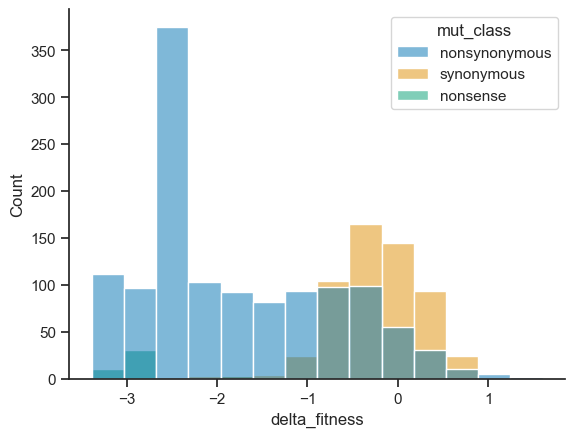

In [9]:
sns.histplot(x='delta_fitness', data=data, hue='mut_class')
sns.despine()
plt.show()

make a list and dictionary and get value for the HA key 

In [50]:
l= ['HA','NA']
l

['HA', 'NA']

In [ ]:
d = {'HA': 'Hemagglutinin', 'NA': 'Neuraminidase'}
#get value from the dictionary for the key HA key:value 
d['HA']

'Hemagglutinin'

In [21]:
heatmap = alt.Chart(ha_mut_effects).mark_rect().encode(
    x=alt.X('codon_site:O', title='site'),
    y=alt.Y('mut_aa:O', title='Amino Acid'),
    color=alt.Color('delta_fitness:Q', title='Fitness', scale=alt.Scale(range=['red', 'white', 'black'], # Custom blue-grey-red range
                                    domainMid=0))
).properties(
    title='My Altair Heatmap'
)
heatmap.display()

alt.Chart(...)

Week 3 
** Using heat map to find out where the neutral in lab and deleterious in nature are**
